# EXPLORING FRED DATA

We download the latest FRED DJIA DATA from https://fred.stlouisfed.org/series/DJIA in CSV format & load it into pandas

> Click on the main link and in the homepage, click on DOWNLOAD, then right-click on the .csv file or any other file type to get the link of that particular file, and upload it in pandas (GOOGLE COLAB) as a dataframe



## Fetching the data

In [18]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DJIA&scale=left&cosd=2021-03-23&coed=2026-03-23&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%20Close&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-03-24&revision_date=2026-03-24&nd=2016-03-24"

In [19]:
# df stands for dataframe, only used to upload new dataframe in PANDAS
import pandas as pd
df =pd.read_csv(URL)
# to check the whole dataframe
df
# to check the column in dataframe
df.columns

Index(['observation_date', 'DJIA'], dtype='object')

## Analysis of Code quality

In [20]:
# MISSING VALUES using .isnull() funtion > might not be so helpful for large dataset
# gives back a data frame, but instead of seeing the values, you get the true or false value of whether that value is null or not.

df.isnull()

,observation_date,DJIA
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
1300,False,False
1301,False,False
1302,False,False
1303,False,False


In [21]:
# we can sum up total number of missing values by column

df.isnull().sum()

,0
observation_date,0
DJIA,49


In [22]:
#  we can also sum up total number of missing values for the entire dataframe
#  It tells total 49 null values. Why? Because, well, they just added both of them, and 0 plus 49 is 49.
df.isnull().sum().sum()

np.int64(49)

In [23]:
# We can also put this in the variable and print it
number_of_nulls = df.isnull().sum().sum()
print("There are " + str(number_of_nulls) + " null values")

There are 49 null values


In [24]:
print("These are the columns for null values")
df.isnull().sum()

These are the columns for null values


,0
observation_date,0
DJIA,49


In [25]:
# HOW CLEAN IS THE DATASET # Let's take it further # 49 NULL VALUES (is it good or bad?)
# LENGTH OF THE DATAFRAME ==> rows which is : len(df)
# let's store it in another variable called : num_rows

num_rows = len(df)
null_ratio = number_of_nulls/num_rows
null_ratio

# We can use FSTRINGS to in python to format our strings # Besides DICTIONARY, we can use curly bracket {} in FSTRING format of Python.

print(f"The null ratio is {null_ratio*100} %")


The null ratio is 3.7547892720306515 %


In [26]:
# We can also do some formatting, like, the thing is .2F (to keep only 2 decimal places), to format the string, which takes the whole number.
print(f"The null ratio is {null_ratio*100:.2F} %")

# or we can
print(f"{null_ratio*100:.3F} % of the data is null")

The null ratio is 3.75 %
3.755 % of the data is null


## We can create a graph to visualize the data

<Axes: xlabel='observation_date', ylabel='DJIA'>

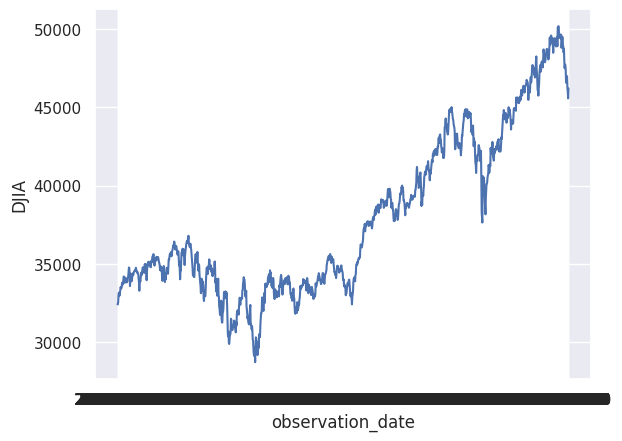

In [27]:
# We can call seaborn library to have access to better visualization

import seaborn as sns

sns.lineplot(df, x="observation_date", y="DJIA")

<Axes: title={'center': 'DJIA over time'}, xlabel='observation_date', ylabel='DJIA'>

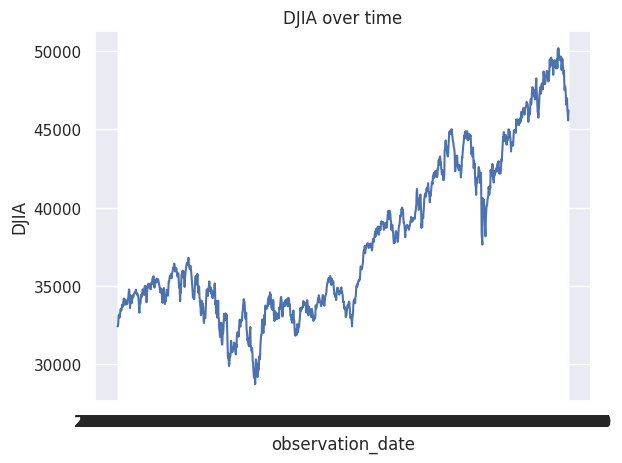

In [28]:
# Also we can google: seaborn documentation to look through to find eg. title for the graph & also other methods
# to create a TITLE for the graph

import seaborn as sns
# sns.set_theme() helps us to create a different theme for the chart
sns.set_theme()

ax = sns.lineplot(df, x="observation_date", y="DJIA")
ax.set (
    title="DJIA over time"
)
ax

# Cleaning the data

In [29]:
# df.dropna() => DROPS ALL MISSING VALUES
# df.dropna(axis=1) => DROPS na VALUES ONLY FROM COLUMNS THAT CONTAIN na VALUES (if cols doesn't have any missing values, it won't be dropped)
# df.dropna(thresh=2) => SETS A THRESHOLD (na values will only be dropped if that threshold is met)
# df.dropna(value="new value") => will fill the missing value with the one that you specify

In [30]:
# drop all the rows by using len(df) which has null values # first by printing original lengh() or row and after dropped
print(len(df))
print(len(df.dropna(axis=0, how='any')))

# we drop the rows that contain ANY NaN/null values
df=df.dropna(axis=0, how='any')
df




1305
1256


,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


## We can manipulate collumns

In [42]:
# DROPING COLUMNS WITHIN DATAFRAME (we can drop one col at a time or multiple cols in one go using a list object)
# current df as only 2 cols and let's add another col (S&P), so that we can attempt to drop the column for instance.
# Here we create a new column
df["S&P"] = df["DJIA"]/10  # With this, S$P column is added in df
df

# we can drop the new column using:

df.drop(["S&P"], axis=1, inplace=True)
df

# above drop is strictly equivalent to below by assigning to df
# excludes inplace=True
# df =df.drop(["S&P"], axis=1)

,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47
